# Isotropy studies for Fermi 4LAT catalogues

Notebook to repeat the isotropy studies initially performed by Cristina Lagunas Gualda

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os

from astropy.coordinates import angular_separation
from scipy import stats
from scipy.stats import distributions, uniform

In [2]:
def mykstest_lons(data):
    s = np.linspace(1/len(data),1,len(data))
    cumul_data = np.sort(data)/360.
    diffs = np.abs(s-cumul_data)
    ts = np.max(diffs)
    pval = distributions.kstwo.sf(ts, len(data))
    return pval

def cdf_lats(x):
    x = np.sin(np.deg2rad(x))
    cut_lat = 10.
    cut_lat_rad = np.deg2rad(cut_lat)
    norm = 2*(1-np.sin(cut_lat_rad))
    cdf = np.empty(len(x))
    cdf[x<=np.sin(-cut_lat_rad)] = (x[x<=np.sin(-cut_lat_rad)] + 1) / norm
    cdf[x>=np.sin(cut_lat_rad)] = (
        x[x>=np.sin(cut_lat_rad)] + 1 - 2 * np.sin(cut_lat_rad)
    ) / norm
    return cdf

def mykstest_lats(data):
    s = np.linspace(1/len(data),1,len(data))
    cumul_data = cdf_lats(np.sort(data))
    diffs = np.abs(s-cumul_data)
    ts = np.max(diffs)
    pval = distributions.kstwo.sf(ts, len(data))
    return pval

def mykstest_lon_lat(cat, print_pvals=True):
    pval_lon = mykstest_lons(cat["GLON"])
    pval_lat = mykstest_lats(cat["GLAT"])
    if print_pvals:
        print(f"KS test, pval latitude: {pval_lat}.\t pval longitude: {pval_lon}")
    return pval_lat, pval_lon

def weighted_means_stds_lats(cat):
    cdf = stats.ecdf(cat["Energy_Flux100"]).cdf
    probs = cdf.probabilities[:-1] - cdf.probabilities[1:]
    all_vals = []
    for i in range(200):
        rnd_weights = stats.rv_histogram(
            (probs, cdf.quantiles)
        ).rvs(size=len(cat))
        rnd_lat_pos = uniform.rvs(
            size=int(len(cat["GLAT"])/2.)
        ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.))
        addition = 0
        if len(cat["GLAT"])%2 != 0.:
            addition = 1
        rnd_lat_neg = - ( uniform.rvs(
            size=int(len(cat["GLAT"])/2. + addition)
        ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.)))
        rnd_lat = np.append(rnd_lat_pos, rnd_lat_neg)
        vals, quantiles, _ = plt.hist(
            rnd_lat, bins=20, weights=rnd_weights, density=True
        )
        plt.close()
        all_vals.append(vals)
    all_vals = np.array(all_vals)
    means = np.array([np.mean(all_vals[:,i]) for i in range(len(all_vals[0]))])
    stds = np.array([np.std(all_vals[:,i]) for i in range(len(all_vals[0]))])
    xs = (quantiles[:-1] + quantiles[1:])/2.

    return means, stds, xs

def weighted_means_stds_lons(cat):
    cdf = stats.ecdf(cat["Energy_Flux100"]).cdf
    probs = cdf.probabilities[:-1] - cdf.probabilities[1:]
    all_vals = []
    for i in range(200):
        rnd_weights = stats.rv_histogram(
            (probs, cdf.quantiles)
        ).rvs(size=len(cat))
        rnd_lon = uniform.rvs(
            size=int(len(cat["GLON"]))
        ) * 360.
        vals, quantiles, _ = plt.hist(
            rnd_lon, bins=20, weights=rnd_weights, density=True
        )
        plt.close()
        all_vals.append(vals)
    all_vals = np.array(all_vals)
    means = np.array([np.mean(all_vals[:,i]) for i in range(len(all_vals[0]))])
    stds = np.array([np.std(all_vals[:,i]) for i in range(len(all_vals[0]))])
    xs = (quantiles[:-1] + quantiles[1:])/2.

    return means, stds, xs

In [3]:
def perform_cuts_studies(name_cat = "table_4LAC.fits"):

    alertstack_data_dir = "../../alertstack/data/"
    with fits.open(os.path.join(alertstack_data_dir, name_cat)) as hdul:
        cat = hdul[1].data
        header = hdul[1].header
    cat = np.sort(cat, order="Energy_Flux100")[::-1]
    
    #blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
    blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
    
    mask = np.array([x["CLASS"] in blazar_class for x in cat])
    blazars = np.array(cat[mask])
    
    blazars_cuts = list()
    pvals_lats = list()
    pvals_lons = list()
    for i in range(5):
        cut_e = -12. + 0.1*i
        mask_e = np.array([x["Energy_Flux100"]>10**cut_e for x in blazars])
        blazars_cut = np.array(blazars[mask_e])
        surviving_flux = np.sum(blazars_cut["Energy_Flux100"])
        total_flux = np.sum(blazars["Energy_Flux100"])
        surviving_flux_ratio = surviving_flux / total_flux
        print(f"cut_e: {cut_e}\tSurviving blazars: {len(blazars_cut)}\tSurviving flux: {surviving_flux_ratio}")
        blazars_cuts.append(blazars_cut)
        pval_lat, pval_lon = mykstest_lon_lat(blazars_cut)
        pvals_lats.append(pval_lat)
        pvals_lons.append(pval_lon)
    
    rnd_lat_pos = uniform.rvs(
        size=int(len(blazars_cuts[-1]["GLAT"])/2.)
    ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.))
    rnd_lat_neg = - ( uniform.rvs(
        size=int(len(blazars_cuts[-1]["GLAT"])/2.)
    ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.)) )
    rnd_lat = np.append(rnd_lat_pos, rnd_lat_neg)
    
    plt.hist(
        rnd_lat,
        bins=20, density=True,
        color="white",
        label="cut, p-value"
    )
    plt.hist(
        rnd_lat,
        bins=20, density=True,
    )
    
    for i in range(5):
        cut_e = -12. + 0.1*i
        pval = pvals_lats[i]
        catcut = blazars_cuts[i]
        plt.hist(
            np.sin(np.deg2rad(catcut["GLAT"])),
            bins=20, histtype='step', density=True,
            label=f"{cut_e} {round(pval,2):.2f}", linewidth=2,
        )
    
    plt.xlabel("sin(b)")
    plt.ylabel("Density")
    plt.title("|b| > 10 degrees")
    
    plt.legend(loc=(1.02, 0.4))

    plt.savefig(
        f"../../alertstack/scramble_catalogues/figures/fermi_isotropy/{name_cat.split('.')[0]}_lat",
        dpi=200,
        bbox_inches="tight"
    )
    
    plt.show()
    plt.close()
    
    rnd_lon = uniform.rvs(
        size=int(len(blazars_cuts[-1]["GLON"]))
    ) * 360.
    
    plt.hist(
        rnd_lon,
        bins=20, density=True,
        color="white",
        label="cut, p-value"
    )
    plt.hist(
        rnd_lon,
        bins=20, density=True,
    )
    
    for i in range(5):
        cut_e = -12. + 0.1*i
        pval = pvals_lons[i]
        catcut = blazars_cuts[i]
        plt.hist(
            catcut["GLON"],
            bins=20, histtype='step', density=True,
            label=f"{cut_e} {round(pval,2):.2f}", linewidth=2,
        )
    
    plt.xlabel("longitude [deg]")
    plt.ylabel("Density [deg-1]")
    plt.title("|b| > 10 degrees")
    
    plt.legend(loc=(1.02, 0.4))

    plt.savefig(
        f"../../alertstack/scramble_catalogues/figures/fermi_isotropy/{name_cat.split('.')[0]}_lon",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    ### weighted histograms
    
    means, stds, xs = weighted_means_stds_lats(blazars_cuts[-1])
    
    plt.errorbar(
        xs, means, stds, marker='o',
        linestyle="", label="Weighted MC"
    )
    
    for i in range(5):
        cut_e = -12. + 0.1*i
        pval = pvals_lats[i]
        catcut = blazars_cuts[i]
        print(f"cut: {cut_e} ")
        lat_dens, lat_quantiles, _ = plt.hist(
            np.sin(np.deg2rad(catcut["GLAT"])),
            bins=20, histtype='step', density=True,
            label=f"Cut = {cut_e}", linewidth=2,
            weights=catcut["Energy_Flux100"]
        )

    print(((lat_dens[stds!=0.] - means[stds!=0.])/stds[stds!=0.])**2)
    chi_sq = np.sum(((lat_dens[stds!=0.] - means[stds!=0.])/stds[stds!=0.])**2)
    pval_chisq = 1 - stats.chi2.cdf(chi_sq, len(stds[stds!=0.]))
    print(
        "Chi2 result from comparison with weighted expetations:"
        f" {chi_sq}, pval: {pval_chisq}"
    )
  
    plt.xlabel("sin(b)")
    plt.ylabel("Density")
    plt.title("|b| > 10 degrees")
    
    plt.legend(loc=(1.02, 0.4))

    plt.savefig(
        f"../../alertstack/scramble_catalogues/figures/fermi_isotropy/{name_cat.split('.')[0]}_lat_weight",
        dpi=200,
        bbox_inches="tight"
    )
    
    plt.show()
    plt.close()
    
    means, stds, xs = weighted_means_stds_lons(blazars_cuts[-1])
    
    plt.errorbar(
        xs, means, stds, marker='o',
        linestyle="", label="Weighted MC"
    )
        
    for i in range(5):
        cut_e = -12. + 0.1*i
        pval = pvals_lons[i]
        catcut = blazars_cuts[i]
        lon_dens, lon_quantiles, _ = plt.hist(
            catcut["GLON"],
            bins=20, histtype='step', density=True,
            label=f"Cut = {cut_e}", linewidth=2,
            weights=catcut["Energy_Flux100"]
        )

    print(((lon_dens - means)/stds)**2)
    chi_sq = np.sum(((lon_dens - means)/stds)**2)
    pval_chisq = 1 - stats.chi2.cdf(chi_sq, len(lon_dens))
    print(
        "Chi2 result from comparison with weighted expetations:"
        f" {chi_sq}, pval: {pval_chisq}"
    )
    
    plt.xlabel("longitude [deg]")
    plt.ylabel("Density [deg-1]")
    plt.title("|b| > 10 degrees")
    
    plt.legend(loc=(1.02, 0.4))

    plt.savefig(
        f"../../alertstack/scramble_catalogues/figures/fermi_isotropy/{name_cat.split('.')[0]}_lon_weight",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

cut_e: -12.0	Surviving blazars: 2760	Surviving flux: 0.998652458190918
KS test, pval latitude: 1.868991853251229e-05.	 pval longitude: 0.03262472473330258
cut_e: -11.9	Surviving blazars: 2682	Surviving flux: 0.9952264428138733
KS test, pval latitude: 0.00033610999901426597.	 pval longitude: 0.06296728188136858
cut_e: -11.8	Surviving blazars: 2519	Surviving flux: 0.9861823916435242
KS test, pval latitude: 0.0012188251282138063.	 pval longitude: 0.15642201582769577
cut_e: -11.7	Surviving blazars: 2257	Surviving flux: 0.9679204821586609
KS test, pval latitude: 0.028356618860199134.	 pval longitude: 0.234356347747542
cut_e: -11.6	Surviving blazars: 1916	Surviving flux: 0.9380135536193848
KS test, pval latitude: 0.19815898677641364.	 pval longitude: 0.702349312873815


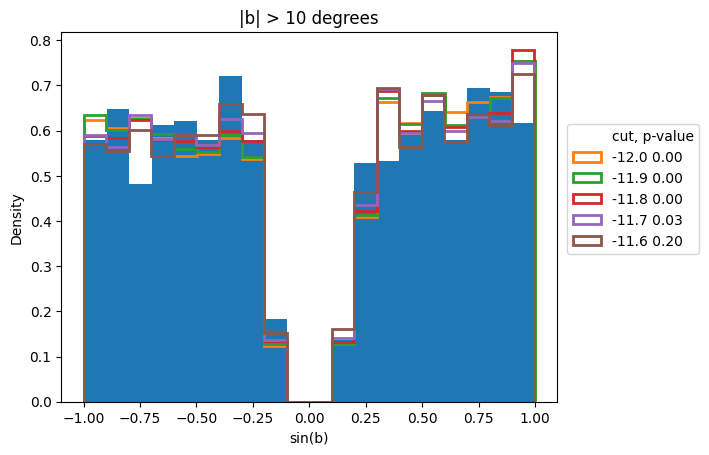

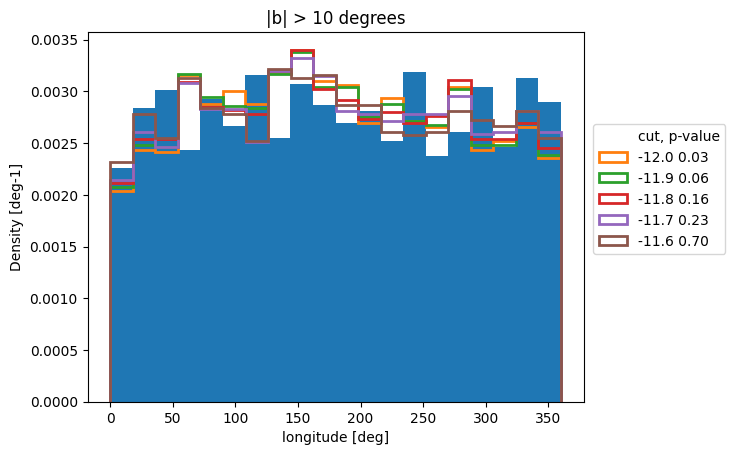

cut: -12.0 
cut: -11.9 
cut: -11.8 
cut: -11.7 
cut: -11.6 
[2.00913111e+00 4.10498067e-01 3.29175528e-01 7.99935385e+00
 1.34284173e-01 1.12080614e-01 3.76507421e-01 1.07984555e-01
 5.27167209e-02 1.55070471e-04 5.20194860e-01 2.97364609e-01
 4.21833601e-01 6.90947138e-01 2.06353887e+00 3.47082234e-01
 9.58554092e-04 9.46687257e+00]
Chi2 result from comparison with weighted expetations: 25.34067954547237, pval: 0.11581619404570265


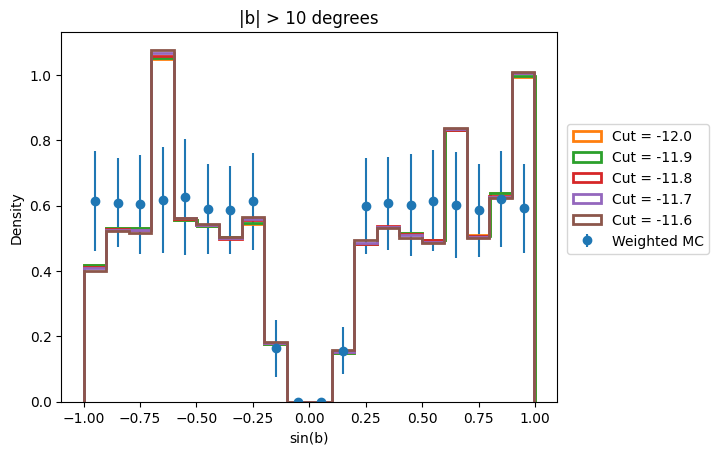

[1.63098263e-01 6.37597868e-02 2.00626778e+00 2.87686160e-01
 1.59033626e+01 1.43097420e-01 1.76965760e+00 1.75810923e+00
 8.22144832e-02 1.64524393e+00 6.50529765e-04 1.83666473e-01
 1.40756894e-01 2.65783419e-01 9.28925293e-01 1.00050013e+00
 4.92608423e-02 6.58449031e-02 3.65064198e-01 1.48403881e-01]
Chi2 result from comparison with weighted expetations: 26.971353772955055, pval: 0.13607186076407773


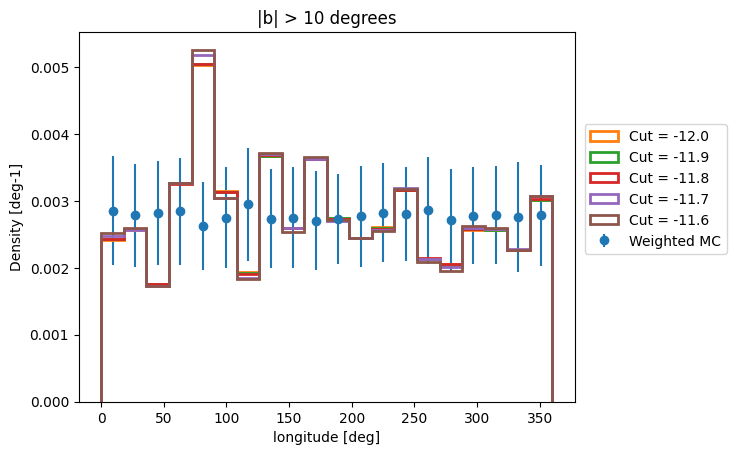

In [4]:
perform_cuts_studies()

cut_e: -12.0	Surviving blazars: 3018	Surviving flux: 0.9986096024513245
KS test, pval latitude: 1.6949150309564823e-05.	 pval longitude: 0.014959552451444539
cut_e: -11.9	Surviving blazars: 2932	Surviving flux: 0.9952530264854431
KS test, pval latitude: 0.0003491577671409751.	 pval longitude: 0.039280892257635314
cut_e: -11.8	Surviving blazars: 2754	Surviving flux: 0.9864620566368103
KS test, pval latitude: 0.0012936271783399284.	 pval longitude: 0.09213164143987573
cut_e: -11.7	Surviving blazars: 2461	Surviving flux: 0.968332052230835
KS test, pval latitude: 0.031871381303920976.	 pval longitude: 0.1669043521438115
cut_e: -11.6	Surviving blazars: 2089	Surviving flux: 0.9393209218978882
KS test, pval latitude: 0.13455115477275936.	 pval longitude: 0.590136769041801


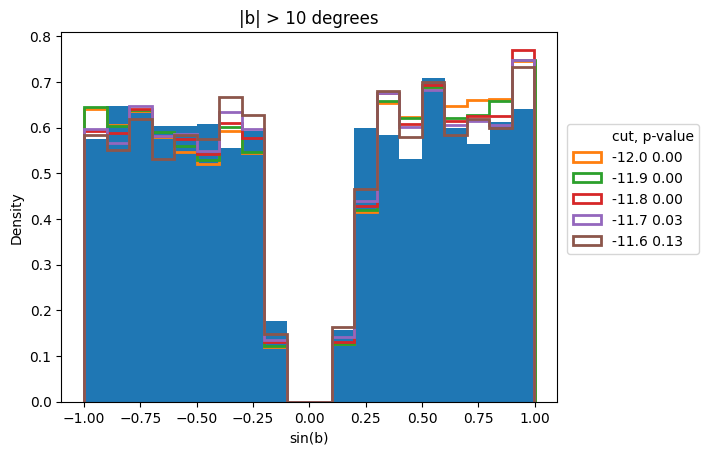

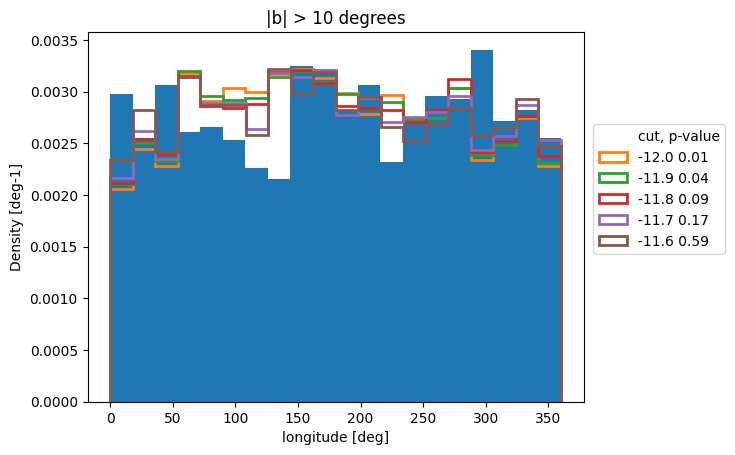

cut: -12.0 
cut: -11.9 
cut: -11.8 
cut: -11.7 
cut: -11.6 
[1.76212427 0.90290162 0.74607965 9.52134875 0.48600179 0.1518276
 0.14487804 0.34672291 0.27358921 0.03674553 0.90375381 0.19964736
 0.48825635 0.32425805 1.74110055 0.77724744 1.21101462 6.32162777]
Chi2 result from comparison with weighted expetations: 26.339125311933966, pval: 0.09225297210863415


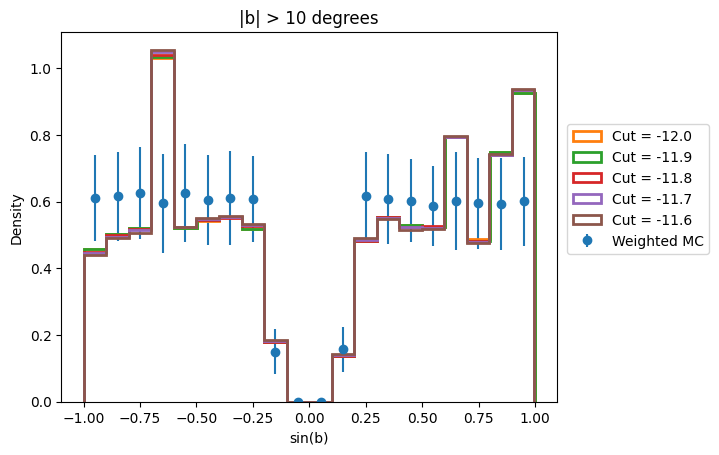

[ 0.4249354   0.0697184   2.67049331  0.314661   10.2344466   0.46428692
  0.90729782  1.83091926  0.42440556  2.7280231   0.02946347  0.12910842
  0.07995998  0.02031775  0.17450374  1.49588583  0.3823348   0.02302589
  0.16021446  0.01408986]
Chi2 result from comparison with weighted expetations: 22.578091573136923, pval: 0.30998262893780226


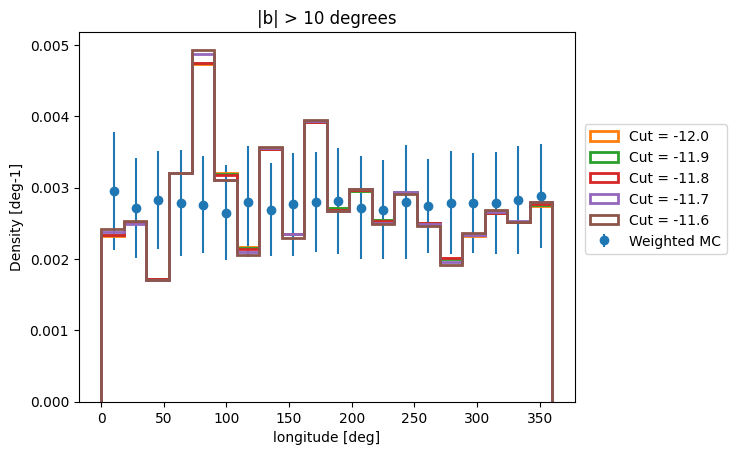

In [5]:
perform_cuts_studies(name_cat="table-4LAC-DR2-h.fits")

cut_e: -12.0	Surviving blazars: 3125	Surviving flux: 0.9936019778251648
KS test, pval latitude: 0.0008191557361086429.	 pval longitude: 0.03992921028528007
cut_e: -11.9	Surviving blazars: 2939	Surviving flux: 0.9854530692100525
KS test, pval latitude: 0.00891878085428475.	 pval longitude: 0.16681297458792965
cut_e: -11.8	Surviving blazars: 2653	Surviving flux: 0.9697197675704956
KS test, pval latitude: 0.012063188116985849.	 pval longitude: 0.35462953797077323
cut_e: -11.7	Surviving blazars: 2269	Surviving flux: 0.9434078335762024
KS test, pval latitude: 0.1502295077656145.	 pval longitude: 0.6370566482893311
cut_e: -11.6	Surviving blazars: 1905	Surviving flux: 0.9118748307228088
KS test, pval latitude: 0.31980803120957213.	 pval longitude: 0.7994032366638005


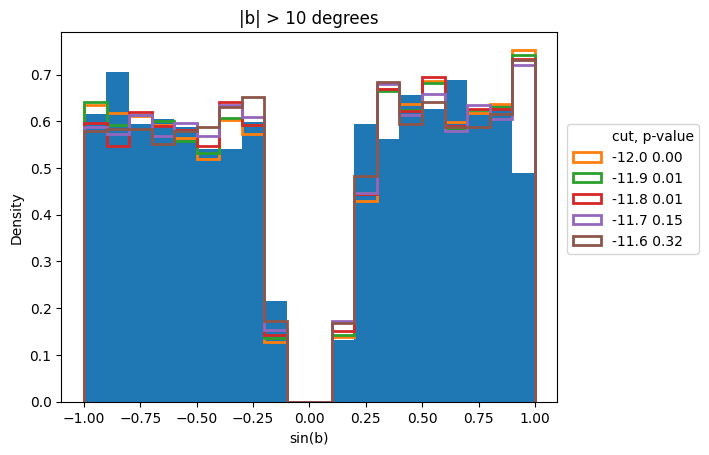

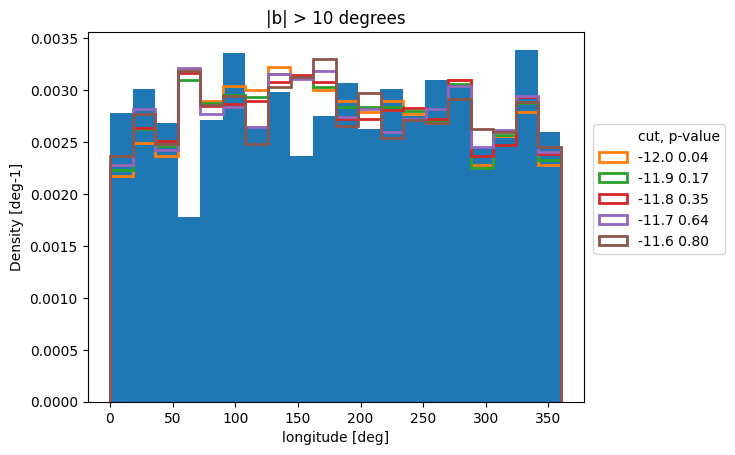

cut: -12.0 
cut: -11.9 
cut: -11.8 
cut: -11.7 
cut: -11.6 
[1.87203413e+00 5.01697934e-02 1.00130877e-01 9.20553478e+00
 2.74535580e-01 1.29782309e-01 7.33255781e-01 1.02754074e-01
 3.67276161e-01 3.71770987e-04 6.20918290e-01 2.71511869e-01
 4.02464826e-01 8.71941632e-01 1.64823877e+00 4.93176662e-01
 1.24801624e-01 6.64822207e+00]
Chi2 result from comparison with weighted expetations: 23.917121002515938, pval: 0.1577618299126624


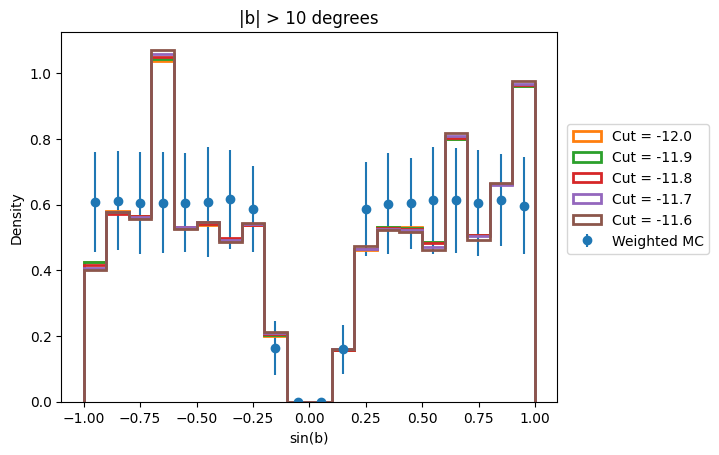

[1.43816218e-01 5.64454631e-02 1.64424984e+00 1.33957989e-01
 7.56315218e+00 4.27666452e-01 2.13924269e+00 1.67531017e+00
 1.76092181e-02 1.54591118e+00 2.17231376e-02 2.39949026e-01
 9.19776412e-03 3.34457562e-01 1.44883601e+00 9.81940111e-01
 6.14555724e-03 1.15015208e-01 4.68698701e-01 6.73676520e-02]
Chi2 result from comparison with weighted expetations: 19.04069212042898, pval: 0.5191824166096219


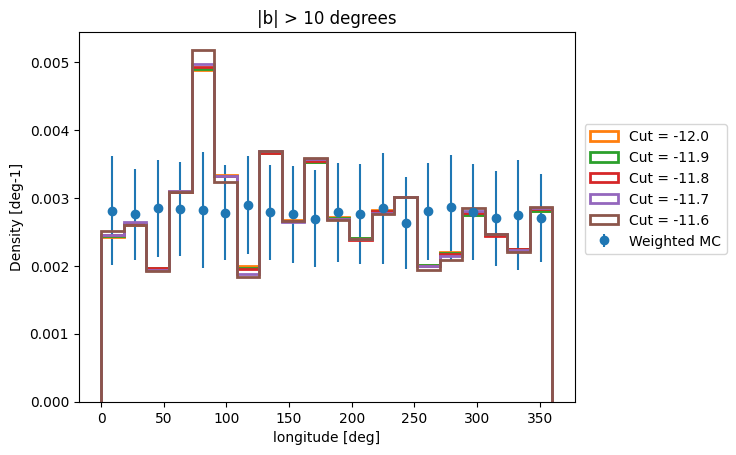

In [6]:
perform_cuts_studies(name_cat="table-4LAC-DR3-h.fits")

In [7]:
def get_ang_dists(rnd_lat, rnd_lon):
    ang_seps = list()
    for i, (lon, lat) in enumerate(zip(rnd_lon, rnd_lat)):
        rnd_lon_rad_reduced = np.delete(rnd_lon, i)
        rnd_lat_rad_reduced = np.delete(rnd_lat, i)
        ang_sep = np.rad2deg(
            angular_separation(
                lat,
                lon,
                rnd_lat_rad_reduced,
                rnd_lon_rad_reduced,
            )
        )
        ang_seps.append(ang_sep)
    ang_seps = np.concatenate(ang_seps)
    return ang_seps

name_cat = "table-4LAC-DR2-h.fits"
alertstack_data_dir = "../../alertstack/data/"
with fits.open(os.path.join(alertstack_data_dir, name_cat)) as hdul:
    cat = hdul[1].data
    header = hdul[1].header
cat = np.sort(cat, order="Energy_Flux100")[::-1]

#blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]

mask = np.array([x["CLASS"] in blazar_class for x in cat])
blazars = np.array(cat[mask])

blazars_cuts = []
for i in range(5):
    cut_e = -12. + 0.1*i
    print(f"cut_e: {cut_e}")
    mask_e = np.array([x["Energy_Flux100"]>10**cut_e for x in blazars])
    blazars_cut = np.array(blazars[mask_e])
    blazars_cuts.append(blazars_cut)

mc_ang_seps = list()
for j in range(50):
    print(j)
    rnd_lon = uniform.rvs(
        size=int(len(blazars["GLON"]))
    ) * 360.
    rnd_lat_pos = uniform.rvs(
        size=int(len(blazars["GLAT"])/2.)
    ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.))
    addition = 0
    if len(blazars["GLAT"])%2 != 0.:
        addition = 1
    rnd_lat_neg = - ( uniform.rvs(
        size=int(len(blazars["GLAT"])/2.  + addition)
    ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.)))
    rnd_lat = np.append(rnd_lat_pos, rnd_lat_neg)
    
    rnd_lon_rad = np.deg2rad(np.array(rnd_lon))
    rnd_lat_rad = np.arcsin(np.array(rnd_lat))
    
    ang_seps = get_ang_dists(rnd_lon_rad, rnd_lat_rad)
    vals, quantiles, _ = plt.hist(ang_seps, bins=20, range=(0,180))
    plt.close()
    mc_ang_seps.append(vals)
    xs = (quantiles[:-1] + quantiles[1:])/2.

mc_ang_seps = np.array(mc_ang_seps)
mc_means = np.array([np.mean(mc_ang_seps[:,i]) for i in range(len(mc_ang_seps[0]))])
mc_stds = np.array([np.std(mc_ang_seps[:,i]) for i in range(len(mc_ang_seps[0]))])

cut_e: -12.0
cut_e: -11.9
cut_e: -11.8
cut_e: -11.7
cut_e: -11.6
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


Text(0.5, 0, 'Angular distance between blazar pairs [deg]')

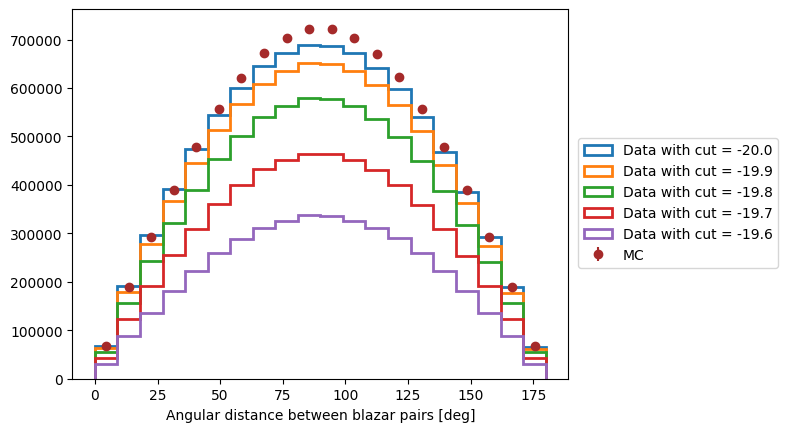

In [8]:
for i, cat in enumerate(blazars_cuts):
    cut = -20.0 + i * 0.1
    ang_seps_real = get_ang_dists(
        np.deg2rad(cat["GLON"]),
        np.deg2rad(cat["GLAT"])
    )
    plt.hist(
        ang_seps_real, bins=20, range=(0,180), histtype='step', linewidth=2,
        label=f"Data with cut = {cut}"
    )
plt.errorbar(
    xs, mc_means, mc_stds, marker='o', linestyle='', color="brown",
    label="MC"
)
plt.legend(loc=(1.02,0.3))
plt.xlabel("Angular distance between blazar pairs [deg]")

In [9]:
def get_ang_dists(rnd_lat, rnd_lon):
    ang_seps = list()
    for i, (lon, lat) in enumerate(zip(rnd_lon, rnd_lat)):
        rnd_lon_rad_reduced = np.delete(rnd_lon, i)
        rnd_lat_rad_reduced = np.delete(rnd_lat, i)
        ang_sep = np.rad2deg(
            angular_separation(
                lat,
                lon,
                rnd_lat_rad_reduced,
                rnd_lon_rad_reduced,
            )
        )
        ang_seps.append(ang_sep)
    ang_seps = np.concatenate(ang_seps)
    return ang_seps

def uniform_2d_test(name_cat="table_4LAC.fits", density=False):
    alertstack_data_dir = "../../alertstack/data/"
    with fits.open(os.path.join(alertstack_data_dir, name_cat)) as hdul:
        cat = hdul[1].data
        header = hdul[1].header
    cat = np.sort(cat, order="Energy_Flux100")[::-1]
    
    #blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
    blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
    
    mask = np.array([x["CLASS"] in blazar_class for x in cat])
    blazars = np.array(cat[mask])
    
    blazars_cuts = []
    for i in range(5):
        cut_e = -12. + 0.1*i
        print(f"cut_e: {cut_e}")
        mask_e = np.array([x["Energy_Flux100"]>10**cut_e for x in blazars])
        blazars_cut = np.array(blazars[mask_e])
        blazars_cuts.append(blazars_cut)
    
    mc_ang_seps = list()
    mc_ang_seps_plot = list()
    for j in range(50):
        if j%10 == 0: print(j)
        rnd_lon = uniform.rvs(
            size=int(len(blazars["GLON"]))
        ) * 360.
        rnd_lat_pos = uniform.rvs(
            size=int(len(blazars["GLAT"])/2.)
        ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.))
        addition = 0
        if len(blazars["GLAT"])%2 != 0.:
            addition = 1
        rnd_lat_neg = - ( uniform.rvs(
            size=int(len(blazars["GLAT"])/2.  + addition)
        ) * (1. - np.sin(np.deg2rad(10.))) + np.sin(np.deg2rad(10.)))
        rnd_lat = np.append(rnd_lat_pos, rnd_lat_neg)
        
        rnd_lon_rad = np.deg2rad(np.array(rnd_lon))
        rnd_lat_rad = np.arcsin(np.array(rnd_lat))
        
        ang_seps = get_ang_dists(rnd_lon_rad, rnd_lat_rad)
        vals, quantiles, _ = plt.hist(ang_seps, bins=20, range=(0,180), density=True)
        vals_plot, quantiles_plot, _ = plt.hist(ang_seps, bins=20, range=(0,180))
        plt.close()
        mc_ang_seps.append(vals)
        mc_ang_seps_plot.append(vals_plot)
        xs = (quantiles[:-1] + quantiles[1:])/2.
    
    mc_ang_seps = np.array(mc_ang_seps)
    mc_ang_seps_plot = np.array(mc_ang_seps_plot)
    mc_means = np.array([np.mean(mc_ang_seps[:,i]) for i in range(len(mc_ang_seps[0]))])
    mc_stds = np.array([np.std(mc_ang_seps[:,i]) for i in range(len(mc_ang_seps[0]))])
    mc_means_plot = np.array(
        [np.mean(mc_ang_seps_plot[:,i]) for i in range(len(mc_ang_seps_plot[0]))]
    )
    mc_stds_plot = np.array(
        [np.std(mc_ang_seps_plot[:,i]) for i in range(len(mc_ang_seps_plot[0]))]
    )
    
    
    for j, cat in enumerate(blazars_cuts):
        cut = -12.0 + j * 0.1
        ang_seps_real = get_ang_dists(
            np.deg2rad(cat["GLON"]),
            np.deg2rad(cat["GLAT"])
        )
        plt.hist(
            ang_seps_real,
            bins=20,
            range=(0,180),
            histtype='step',
            density=False,
            linewidth=2,
            label=f"Data with cut = {cut}"
        )    
    plt.errorbar(
        xs, mc_means_plot, mc_stds_plot, marker='o', linestyle='', color="brown",
        label="MC"
    )
    plt.legend(loc=(1.02,0.3))
    plt.xlabel("Angular distance between blazar pairs [deg]")
    plt.savefig(
        f"../../alertstack/scramble_catalogues/figures/fermi_isotropy/2d_isotropy_{name_cat.split("table-")[-1].split(".")[0]}",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()
    for j, cat in enumerate(blazars_cuts):
        ang_seps_real = get_ang_dists(
            np.deg2rad(cat["GLON"]),
            np.deg2rad(cat["GLAT"])
        )
        real_vals, real_quantiles, _ = plt.hist(
            ang_seps_real,
            bins=20,
            range=(0,180),
            histtype='step',
            density=True
        )
        plt.close()
        chi_sq = np.sum(((real_vals-mc_means)/mc_stds)**2)
        pval_chisq = 1 - stats.chi2.cdf(chi_sq, len(real_vals))
        print(f"cut: {-12.+j*0.1}, chi_sq: {chi_sq}, pval: {pval_chisq}")

cut_e: -12.0
cut_e: -11.9
cut_e: -11.8
cut_e: -11.7
cut_e: -11.6
0
10
20
30
40


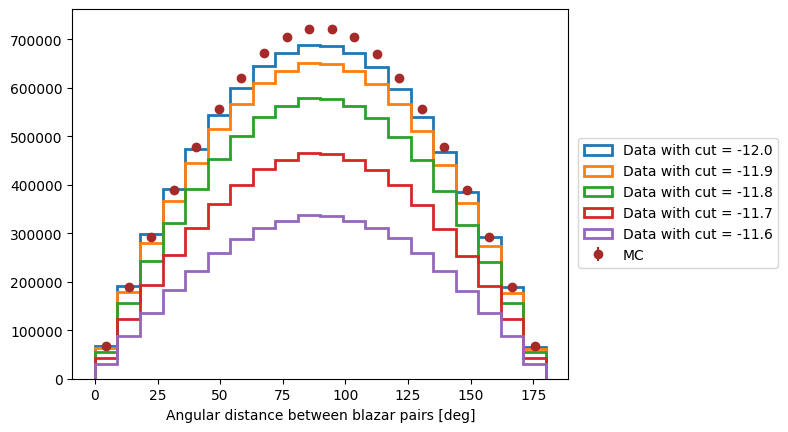

cut: -12.0, chi_sq: 249.97639596657606, pval: 0.0
cut: -11.9, chi_sq: 185.80582260839057, pval: 0.0
cut: -11.8, chi_sq: 85.5434966349547, pval: 4.410957155087658e-10
cut: -11.7, chi_sq: 32.853183511446765, pval: 0.03501346016441442
cut: -11.6, chi_sq: 9.687063809452628, pval: 0.9734978684945552


In [10]:
uniform_2d_test(name_cat="table-4LAC-DR2-h.fits")

cut_e: -12.0
cut_e: -11.9
cut_e: -11.8
cut_e: -11.7
cut_e: -11.6
0
10
20
30
40


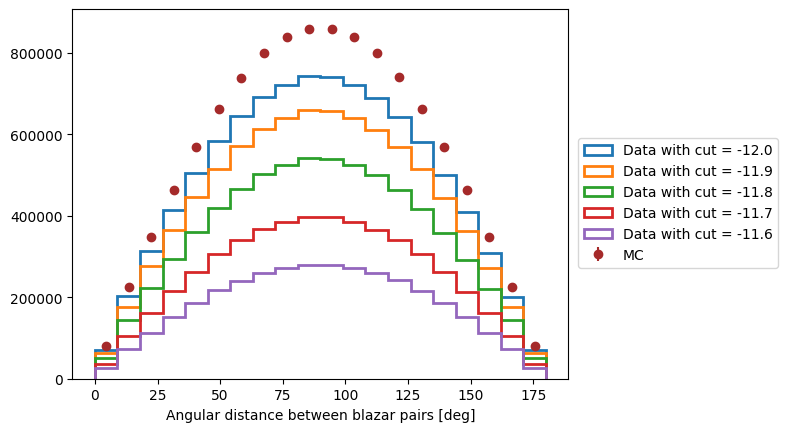

cut: -12.0, chi_sq: 163.27066944211845, pval: 0.0
cut: -11.9, chi_sq: 95.33477116794033, pval: 8.53039860970739e-12
cut: -11.8, chi_sq: 31.61005931754004, pval: 0.047634707230992945
cut: -11.7, chi_sq: 13.916772477029967, pval: 0.8346905575905321
cut: -11.6, chi_sq: 21.62978260168186, pval: 0.3609327195222376


In [11]:
uniform_2d_test(name_cat="table-4LAC-DR3-h.fits")

cut_e: -12.0
cut_e: -11.9
cut_e: -11.8
cut_e: -11.7
cut_e: -11.6
0
10
20
30
40


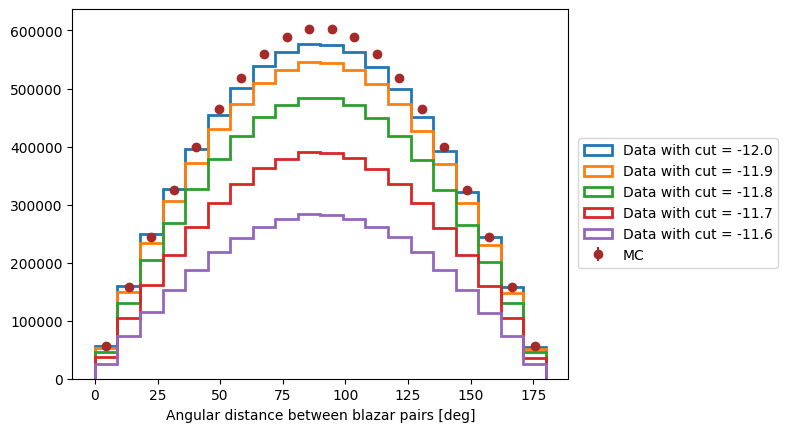

cut: -12.0, chi_sq: 256.131259885568, pval: 0.0
cut: -11.9, chi_sq: 192.778648032366, pval: 0.0
cut: -11.8, chi_sq: 95.81867596609145, pval: 7.00162150479855e-12
cut: -11.7, chi_sq: 39.19504162842755, pval: 0.006304697462338971
cut: -11.6, chi_sq: 13.610059559182506, pval: 0.8497038813203823


In [12]:
uniform_2d_test()

In [13]:
help(np.arcsin)

Help on ufunc:

arcsin = <ufunc 'arcsin'>
    arcsin(x, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature, extobj])

    Inverse sine, element-wise.

    Parameters
    ----------
    x : array_like
        `y`-coordinate on the unit circle.
    out : ndarray, None, or tuple of ndarray and None, optional
        A location into which the result is stored. If provided, it must have
        a shape that the inputs broadcast to. If not provided or None,
        a freshly-allocated array is returned. A tuple (possible only as a
        keyword argument) must have length equal to the number of outputs.
    where : array_like, optional
        This condition is broadcast over the input. At locations where the
        condition is True, the `out` array will be set to the ufunc result.
        Elsewhere, the `out` array will retain its original value.
        Note that if an uninitialized `out` array is created via the default
        ``out=None``, 

In [14]:
from astropy.coordinates import angular_separation

np.rad2deg(
    angular_separation(
        np.deg2rad(rnd_lat),
        np.deg2rad(rnd_lon),
        np.deg2rad(rnd_lat),
        np.deg2rad(rnd_lon),
    )
)

array([0., 0., 0., ..., 0., 0., 0.])

cut_e: -11.6


(array([0.00252293, 0.00259259, 0.00172464, 0.00327288, 0.00525651,
        0.00303589, 0.00182699, 0.00371653, 0.00253451, 0.00364979,
        0.0027114 , 0.00244403, 0.00254565, 0.00317105, 0.00208359,
        0.00195207, 0.00261859, 0.00259666, 0.00226171, 0.00307331]),
 array([2.23831236e-01, 1.82122478e+01, 3.62006645e+01, 5.41890793e+01,
        7.21774979e+01, 9.01659164e+01, 1.08154327e+02, 1.26142746e+02,
        1.44131165e+02, 1.62119583e+02, 1.80108002e+02, 1.98096405e+02,
        2.16084824e+02, 2.34073242e+02, 2.52061661e+02, 2.70050079e+02,
        2.88038483e+02, 3.06026917e+02, 3.24015320e+02, 3.42003754e+02,
        3.59992157e+02]),
 [<matplotlib.patches.Polygon at 0x7f2b5896deb0>])

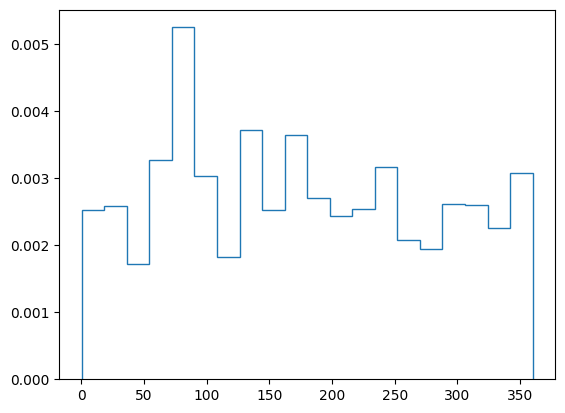

In [15]:
name_cat = "table_4LAC.fits"
alertstack_data_dir = "../../alertstack/data/"
with fits.open(os.path.join(alertstack_data_dir, name_cat)) as hdul:
    cat = hdul[1].data
    header = hdul[1].header
cat = np.sort(cat, order="Energy_Flux100")[::-1]

#blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]

mask = np.array([x["CLASS"] in blazar_class for x in cat])
blazars = np.array(cat[mask])

cut_e = -12. + 0.1*4
print(f"cut_e: {cut_e}")
mask_e = np.array([x["Energy_Flux100"]>10**cut_e for x in blazars])
blazars_cut = np.array(blazars[mask_e])

plt.hist(
    blazars_cut["GLON"],
    bins=20, histtype='step', density=True, weights=blazars_cut["Energy_Flux100"]
    #label=f"{cut_e} {round(pval,2):.2f}", linewidth=2,
)

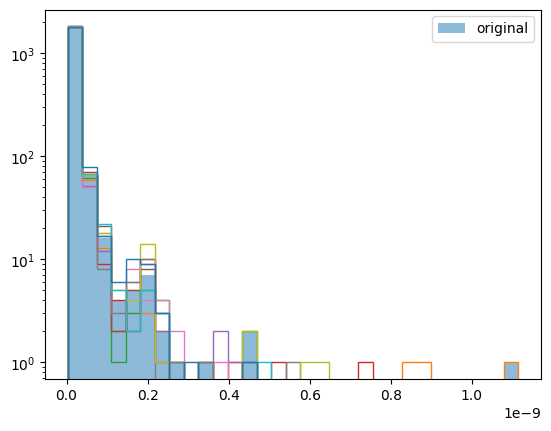

In [16]:
logbins = np.logspace(
    np.log10(np.min(blazars_cut["Energy_Flux100"])),
    np.log10(np.max(blazars_cut["Energy_Flux100"])),
    30
)
energyrange = (
    np.min(blazars_cut["Energy_Flux100"]),
    np.max(blazars_cut["Energy_Flux100"])
)
plt.hist(
    blazars_cut["Energy_Flux100"],
    bins=31,
    range=energyrange,
    alpha=0.5,
    label="original"
)

cdf = stats.ecdf(blazars_cut["Energy_Flux100"]).cdf
probs = cdf.probabilities[:-1] - cdf.probabilities[1:]

for i in range(10):
    plt.hist(
        stats.rv_histogram((probs, cdf.quantiles)).rvs(size=len(blazars_cut)),
        bins=31, histtype='step',
        range=energyrange
    )

#plt.xscale("log")
plt.yscale("log")
plt.legend()

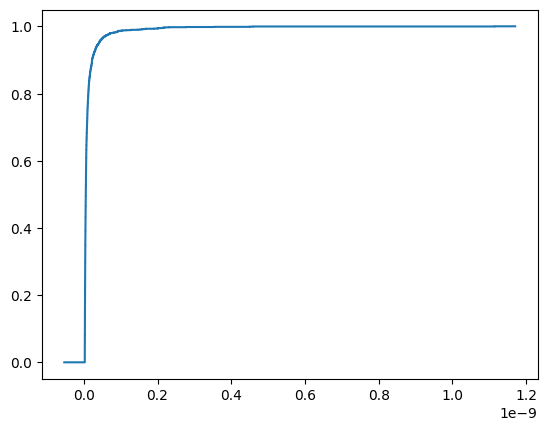

In [17]:
stats.ecdf(blazars_cut["Energy_Flux100"]).cdf.plot()

In [18]:
cdf = stats.ecdf(blazars_cut["Energy_Flux100"]).cdf
uniform.rvs()

0.48530997584670266

In [19]:
cdf.evaluate(0.1e-10)

array(0.7526096)

In [20]:
ecdf = stats.ecdf(blazars_cut["Energy_Flux100"])
ecdf.sf.evaluate(0.1e-10)

array(0.2473904)

In [21]:
probs = cdf.probabilities[:-1] - cdf.probabilities[1:]